# Survival Analysis with Progenetix CNV Data

In this notebook, we build a simple survival analysis example using Progenetix data.

The basic workflow:

1. retrieve sample-level metadata,
2. retreive individual-level data with survival information,
3. retrieve sample-level CNV records,
4. convert CNV records into simple gene-level features,
5. and apply two standard survival analysis methods.

We will use:

- **Kaplan–Meier curves** to compare survival between two groups,
- and a **Cox proportional hazards model** to estimate how a CNV-derived feature is associated with hazard.



## Environment Setup

```bash
conda install -c conda-forge scikit-survival
pip install scikit-survival

In [1]:
import requests
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io

from tqdm.auto import tqdm

from sksurv.util import Surv
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

## Download sample metadata from Progenetix

We begin with the Progenetix `sampletable` service.

This service returns sample annotations in tabular form and supports query filters.
For example, the Progenetix documentation shows that TCGA samples can be retrieved with:

- `filters=pgx:cohort-TCGAcancers`

and that:

- `limit=0` means no result limit.


In [2]:
# -----------------------------
# Cohort definition
# -----------------------------
TARGET_TCGA_PROJECT = "pgx:TCGA-LUAD"   

# -----------------------------
# Progenetix sampletable endpoint
# -----------------------------
SAMPLETABLE_URL = "https://progenetix.org/services/sampletable/"

In [3]:
def fetch_sampletable(filters, limit=0, timeout=120):
    # Download a Progenetix sample table as a pandas DataFrame.
    params = {
        "filters": filters,
        "limit": limit,
    }

    response = requests.get(SAMPLETABLE_URL, params=params, timeout=timeout)
    response.raise_for_status()

    print("Status:", response.status_code)
    print("Final URL:", response.url)
    print("Content-Type:", response.headers.get("Content-Type"))

    text = response.text
    df = pd.read_csv(io.StringIO(text), sep="\t")
    return df

In [4]:
sample_table_df = fetch_sampletable(filters=TARGET_TCGA_PROJECT, limit=0)

print("Shape:", sample_table_df.shape)
print("Columns:")
print(sample_table_df.columns.tolist())
sample_table_df.head()

Status: 200
Final URL: https://progenetix.org/services/sampletable/?filters=pgx%3ATCGA-LUAD&limit=0
Content-Type: text/tsv
Shape: (1110, 42)
Columns:
['biosample_id', 'individual_id', 'biosample_name', 'notes', 'histological_diagnosis_id', 'histological_diagnosis_label', 'pathological_stage_id', 'pathological_stage_label', 'biosample_status_id', 'biosample_status_label', 'sample_origin_type_id', 'sample_origin_type_label', 'sampled_tissue_id', 'sampled_tissue_label', 'tnm', 'tumor_grade_id', 'tumor_grade_label', 'age_iso', 'age_days', 'icdo_morphology_id', 'icdo_morphology_label', 'icdo_topography_id', 'icdo_topography_label', 'pubmed_id', 'pubmed_label', 'cellosaurus_id', 'cellosaurus_label', 'cbioportal_id', 'cbioportal_label', 'tcgaproject_id', 'tcgaproject_label', 'cohorts', 'geoprov_id', 'geoprov_city', 'geoprov_country', 'geoprov_iso_alpha3', 'geoprov_long_lat', 'followup_days', 'sex_id', 'sex_label', 'group_id', 'group_label']


,biosample_id,individual_id,biosample_name,notes,histological_diagnosis_id,histological_diagnosis_label,pathological_stage_id,pathological_stage_label,biosample_status_id,biosample_status_label,...,geoprov_id,geoprov_city,geoprov_country,geoprov_iso_alpha3,geoprov_long_lat,followup_days,sex_id,sex_label,group_id,group_label
0,pgxbs-kftvhozs,pgxind-kftx3k8z,c6eb4188-08b3-444f-b73a-4d247731534f,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27975,Stage IA,EFO:0009654,reference sample,...,cambridge::unitedstates::-71.10561::42.3751,Cambridge,United States,USA,-71.10561::42.3751,NaN,NaN,NaN,NaN,NaN
1,pgxbs-kftvhr8l,pgxind-kftx3pc2,6cc8f2ba-e7b6-4fb8-b16a-7bfe89190f05,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27967,Stage IIA,EFO:0009654,reference sample,...,cambridge::unitedstates::-71.10561::42.3751,Cambridge,United States,USA,-71.10561::42.3751,NaN,NaN,NaN,NaN,NaN
2,pgxbs-kftvhtxc,pgxind-kftx3gj0,39509ea1-e728-4350-b444-798c72ade33a,Primary Tumor,NCIT:C2853,Papillary Adenocarcinoma,NCIT:C27977,Stage IIIA,EFO:0009656,neoplastic sample,...,cambridge::unitedstates::-71.10561::42.3751,Cambridge,United States,USA,-71.10561::42.3751,NaN,NaN,NaN,NaN,NaN
3,pgxbs-kftvi9gl,pgxind-kftx3hff,d2e932cc-71ac-4f88-aa99-7626b2c57e9a,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27976,Stage IB,EFO:0009654,reference sample,...,cambridge::unitedstates::-71.10561::42.3751,Cambridge,United States,USA,-71.10561::42.3751,NaN,NaN,NaN,NaN,NaN
4,pgxbs-kftvi6a1,pgxind-kftx3hwe,ded52bac-fedf-43e0-be97-e261a84383ad,Solid Tissue Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27968,Stage IIB,EFO:0009654,reference sample,...,cambridge::unitedstates::-71.10561::42.3751,Cambridge,United States,USA,-71.10561::42.3751,NaN,NaN,NaN,NaN,NaN


In [5]:
# Columns we want to keep from the sample table
BIOSAMPLE_COLUMNS = [
    "biosample_id",
    "individual_id",
    "biosample_name",
    "notes",
    "histological_diagnosis_id",
    "histological_diagnosis_label",
    "pathological_stage_id",
    "pathological_stage_label",
    "sample_origin_type_id",
    "sample_origin_type_label",
    "sampled_tissue_id",
    "sampled_tissue_label",
    "tcgaproject_id",
    "tcgaproject_label",
    "icdo_morphology_id",
    "icdo_topography_id",
    "icdo_topography_label",
]

BIOSAMPLE_COLUMNS = [c for c in BIOSAMPLE_COLUMNS if c in sample_table_df.columns]

biosample_df = sample_table_df[BIOSAMPLE_COLUMNS].copy()

print("Biosample-level metadata shape:", biosample_df.shape)
biosample_df.head()

Biosample-level metadata shape: (1110, 17)


,biosample_id,individual_id,biosample_name,notes,histological_diagnosis_id,histological_diagnosis_label,pathological_stage_id,pathological_stage_label,sample_origin_type_id,sample_origin_type_label,sampled_tissue_id,sampled_tissue_label,tcgaproject_id,tcgaproject_label,icdo_morphology_id,icdo_topography_id,icdo_topography_label
0,pgxbs-kftvhozs,pgxind-kftx3k8z,c6eb4188-08b3-444f-b73a-4d247731534f,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27975,Stage IA,OBI:0001479,specimen from organism,UBERON:0000178,blood,pgx:TCGA-LUAD,Lung Adenocarcinoma,pgx:icdom-00000,pgx:icdot-C42.0,Blood
1,pgxbs-kftvhr8l,pgxind-kftx3pc2,6cc8f2ba-e7b6-4fb8-b16a-7bfe89190f05,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27967,Stage IIA,OBI:0001479,specimen from organism,UBERON:0000178,blood,pgx:TCGA-LUAD,Lung Adenocarcinoma,pgx:icdom-00000,pgx:icdot-C42.0,Blood
2,pgxbs-kftvhtxc,pgxind-kftx3gj0,39509ea1-e728-4350-b444-798c72ade33a,Primary Tumor,NCIT:C2853,Papillary Adenocarcinoma,NCIT:C27977,Stage IIIA,OBI:0001479,specimen from organism,UBERON:0008948,upper lobe of lung,pgx:TCGA-LUAD,Lung Adenocarcinoma,pgx:icdom-82603,pgx:icdot-C34.1,"Upper lobe, lung"
3,pgxbs-kftvi9gl,pgxind-kftx3hff,d2e932cc-71ac-4f88-aa99-7626b2c57e9a,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27976,Stage IB,OBI:0001479,specimen from organism,UBERON:0000178,blood,pgx:TCGA-LUAD,Lung Adenocarcinoma,pgx:icdom-00000,pgx:icdot-C42.0,Blood
4,pgxbs-kftvi6a1,pgxind-kftx3hwe,ded52bac-fedf-43e0-be97-e261a84383ad,Solid Tissue Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27968,Stage IIB,OBI:0001479,specimen from organism,UBERON:0001062,anatomical entity,pgx:TCGA-LUAD,Lung Adenocarcinoma,pgx:icdom-00000,pgx:icdot-C80.9,Unknown primary site


## Build survival metadata by combining biosample- and individual-level information

The Progenetix sample table is useful for cohort selection and biosample-level metadata, but survival-related information is not always available there.

In our case, each biosample is linked to an `individual_id`.  
We therefore use a two-step strategy:

1. retrieve **biosample-level metadata** from the Progenetix sample table,
2. retrieve **individual-level follow-up metadata** from the Progenetix individual endpoint,
3. and merge the two through `individual_id`.

This is important because survival analysis requires at least:

- a follow-up time,
- and an event indicator.

These fields are available in the individual-level record.

In the Progenetix data model, one individual may have more than one biosample.  
Therefore, after merging biosample- and individual-level metadata, we also need to decide how to handle the one-to-many relationship before building a survival model.

In [6]:
individual_ids = (
    biosample_df["individual_id"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

print("Number of unique individuals:", len(individual_ids))
print(individual_ids[:10])

Number of unique individuals: 518
['pgxind-kftx3k8z', 'pgxind-kftx3pc2', 'pgxind-kftx3gj0', 'pgxind-kftx3hff', 'pgxind-kftx3hwe', 'pgxind-kftx3qrn', 'pgxind-kftx3jim', 'pgxind-kftx3tbm', 'pgxind-kftx3qvy', 'pgxind-kftx3se7']


In [7]:
SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json, text/plain, */*",
})

def fetch_individual_record(individual_id, session=SESSION, timeout=120):
    # Fetch one Progenetix individual record by individual ID.
    url = f"https://progenetix.org/beacon/individuals/{individual_id}/"
    response = session.get(url, timeout=timeout)
    response.raise_for_status()
    return response.json()

In [8]:
def parse_individual_record(data):
    # Parse one Progenetix individual JSON response into a flat dictionary.
    response = data.get("response", {})
    result_sets = response.get("resultSets", [])
    if not result_sets:
        return None

    results = result_sets[0].get("results", [])
    if not results:
        return None

    rec = results[0]

    diseases = rec.get("diseases", [])
    disease_0 = diseases[0] if len(diseases) > 0 else {}

    out = {
        # identifiers
        "individual_id": rec.get("id"),
        "n_diseases": len(diseases),

        # sex
        "sex_id_individual": rec.get("sex", {}).get("id"),
        "sex_label_individual": rec.get("sex", {}).get("label"),

        # top-level survival-related status
        "vital_status": rec.get("vitalStatus", {}).get("status"),

        # top-level info block
        "info_age_at_diagnosis_days": rec.get("info", {}).get("ageAtDiagnosis"),
        "info_days_to_death": rec.get("info", {}).get("daysToDeath"),
        "info_death": rec.get("info", {}).get("death"),
        "info_ethnicity": rec.get("info", {}).get("ethnicity"),
        "info_race": rec.get("info", {}).get("race"),
        "info_year_of_birth": rec.get("info", {}).get("yearOfBirth"),

        # references
        "tcga_case_id": rec.get("references", {}).get("tcgacase", {}).get("id"),
        "tcga_submitter_id": rec.get("references", {}).get("tcgasubmitter", {}).get("id"),

        # disease block 
        "disease_id": disease_0.get("diseaseCode", {}).get("id"),
        "disease_label": disease_0.get("diseaseCode", {}).get("label"),
        "followup_days": disease_0.get("followupDays"),
        "followup_time_iso": disease_0.get("followupTime"),
        "followup_state_id": disease_0.get("followupState", {}).get("id"),
        "followup_state_label": disease_0.get("followupState", {}).get("label"),
        "onset_age_iso": disease_0.get("onset", {}).get("age"),
        "onset_age_days": disease_0.get("onset", {}).get("ageDays"),
        "stage_id_individual": disease_0.get("stage", {}).get("id"),
        "stage_label_individual": disease_0.get("stage", {}).get("label"),
    }

    return out

In [9]:
individual_rows = []
failed_individuals = []

for individual_id in tqdm(individual_ids, desc="Fetching individual records"):
    try:
        data = fetch_individual_record(individual_id)
        row = parse_individual_record(data)
        if row is not None:
            individual_rows.append(row)
        else:
            failed_individuals.append((individual_id, "No result"))
    except Exception as e:
        failed_individuals.append((individual_id, str(e)))

individual_df = pd.DataFrame(individual_rows)

print("Fetched individual rows:", len(individual_df))
print("Failed individual queries:", len(failed_individuals))
individual_df.head()

Fetching individual records:   0%|          | 0/518 [00:00<?, ?it/s]

Fetched individual rows: 518
Failed individual queries: 0


,individual_id,n_diseases,sex_id_individual,sex_label_individual,vital_status,info_age_at_diagnosis_days,info_days_to_death,info_death,info_ethnicity,info_race,...,disease_id,disease_label,followup_days,followup_time_iso,followup_state_id,followup_state_label,onset_age_iso,onset_age_days,stage_id_individual,stage_label_individual
0,pgxind-kftx3k8z,1,NCIT:C20197,male,DECEASED,20576.0,702.0,dead,not hispanic or latino,white,...,NCIT:C3512,Lung Adenocarcinoma,91.0,P3M,EFO:0030049,dead (follow-up status),P56Y4M0D,20575.0,NCIT:C27975,Stage IA
1,pgxind-kftx3pc2,1,NCIT:C20197,male,DECEASED,24725.0,164.0,dead,not hispanic or latino,white,...,NCIT:C2853,Papillary Adenocarcinoma,NaN,NaN,EFO:0030049,dead (follow-up status),P67Y8M9D,24723.0,NCIT:C27967,Stage IIA
2,pgxind-kftx3gj0,1,NCIT:C16576,female,ALIVE,NaN,NaN,alive,not reported,not reported,...,NCIT:C2853,Papillary Adenocarcinoma,NaN,NaN,EFO:0030041,alive (follow-up status),NaN,NaN,NCIT:C27977,Stage IIIA
3,pgxind-kftx3hff,1,NCIT:C16576,female,ALIVE,24241.0,NaN,alive,not hispanic or latino,white,...,NCIT:C3512,Lung Adenocarcinoma,2950.0,P97M,EFO:0030041,alive (follow-up status),P66Y4M12D,24239.0,NCIT:C27976,Stage IB
4,pgxind-kftx3hwe,1,NCIT:C20197,male,ALIVE,23378.0,NaN,alive,not hispanic or latino,white,...,NCIT:C26712,Mucinous Adenocarcinoma,730.0,P24M,EFO:0030041,alive (follow-up status),P64Y0M2D,23377.0,NCIT:C27968,Stage IIB


### Merge Biosample and Individual with individual_id

In [10]:
merged_meta_df = biosample_df.merge(
    individual_df,
    on="individual_id",
    how="left"
)

print("Merged metadata shape:", merged_meta_df.shape)
merged_meta_df.head()

Merged metadata shape: (1110, 39)


,biosample_id,individual_id,biosample_name,notes,histological_diagnosis_id,histological_diagnosis_label,pathological_stage_id,pathological_stage_label,sample_origin_type_id,sample_origin_type_label,...,disease_id,disease_label,followup_days,followup_time_iso,followup_state_id,followup_state_label,onset_age_iso,onset_age_days,stage_id_individual,stage_label_individual
0,pgxbs-kftvhozs,pgxind-kftx3k8z,c6eb4188-08b3-444f-b73a-4d247731534f,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27975,Stage IA,OBI:0001479,specimen from organism,...,NCIT:C3512,Lung Adenocarcinoma,91.0,P3M,EFO:0030049,dead (follow-up status),P56Y4M0D,20575.0,NCIT:C27975,Stage IA
1,pgxbs-kftvhr8l,pgxind-kftx3pc2,6cc8f2ba-e7b6-4fb8-b16a-7bfe89190f05,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27967,Stage IIA,OBI:0001479,specimen from organism,...,NCIT:C2853,Papillary Adenocarcinoma,NaN,NaN,EFO:0030049,dead (follow-up status),P67Y8M9D,24723.0,NCIT:C27967,Stage IIA
2,pgxbs-kftvhtxc,pgxind-kftx3gj0,39509ea1-e728-4350-b444-798c72ade33a,Primary Tumor,NCIT:C2853,Papillary Adenocarcinoma,NCIT:C27977,Stage IIIA,OBI:0001479,specimen from organism,...,NCIT:C2853,Papillary Adenocarcinoma,NaN,NaN,EFO:0030041,alive (follow-up status),NaN,NaN,NCIT:C27977,Stage IIIA
3,pgxbs-kftvi9gl,pgxind-kftx3hff,d2e932cc-71ac-4f88-aa99-7626b2c57e9a,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27976,Stage IB,OBI:0001479,specimen from organism,...,NCIT:C3512,Lung Adenocarcinoma,2950.0,P97M,EFO:0030041,alive (follow-up status),P66Y4M12D,24239.0,NCIT:C27976,Stage IB
4,pgxbs-kftvi6a1,pgxind-kftx3hwe,ded52bac-fedf-43e0-be97-e261a84383ad,Solid Tissue Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27968,Stage IIB,OBI:0001479,specimen from organism,...,NCIT:C26712,Mucinous Adenocarcinoma,730.0,P24M,EFO:0030041,alive (follow-up status),P64Y0M2D,23377.0,NCIT:C27968,Stage IIB


### Build Survival Outcome
Keep one biosample for each individual

In [11]:
survival_df = merged_meta_df.copy()

# Survival time
survival_df["time"] = pd.to_numeric(survival_df["followup_days"], errors="coerce")

def map_event(row):
    """
    Convert individual-level follow-up / vital status into a binary event label.
    0 = alive / censored
    1 = dead / event occurred
    """
    followup_state = str(row.get("followup_state_label", "")).strip().lower()
    vital_status = str(row.get("vital_status", "")).strip().upper()

    if "alive" in followup_state:
        return 0
    if "deceased" in followup_state or "dead" in followup_state:
        return 1

    if vital_status == "ALIVE":
        return 0
    if vital_status == "DECEASED":
        return 1

    return np.nan

survival_df["event"] = survival_df.apply(map_event, axis=1)

# Keep only rows with usable survival data
survival_df = survival_df.dropna(subset=["biosample_id", "individual_id", "time", "event"]).copy()
survival_df["event"] = survival_df["event"].astype(int)

print("Rows with usable survival data:", len(survival_df))
survival_df[[
    "biosample_id",
    "individual_id",
    "time",
    "event",
    "followup_state_label",
    "vital_status",
    "sex_label_individual"
]].head()

Rows with usable survival data: 859


,biosample_id,individual_id,time,event,followup_state_label,vital_status,sex_label_individual
0,pgxbs-kftvhozs,pgxind-kftx3k8z,91.0,1,dead (follow-up status),DECEASED,male
3,pgxbs-kftvi9gl,pgxind-kftx3hff,2950.0,0,alive (follow-up status),ALIVE,female
4,pgxbs-kftvi6a1,pgxind-kftx3hwe,730.0,0,alive (follow-up status),ALIVE,male
5,pgxbs-kftvht79,pgxind-kftx3qrn,2494.0,0,alive (follow-up status),ALIVE,female
6,pgxbs-kftvi2hv,pgxind-kftx3jim,2585.0,0,alive (follow-up status),ALIVE,male


In [12]:
survival_unique_df = (
    survival_df
    .groupby("individual_id")
    .sample(n=1, random_state=42)   
    .copy()
)

print("Rows after keeping one biosample per individual:", len(survival_unique_df))
survival_unique_df[[
    "biosample_id",
    "individual_id",
    "sample_origin_type_label",
    "time",
    "event",
    "sex_label_individual"
]].head()

Rows after keeping one biosample per individual: 391


,biosample_id,individual_id,sample_origin_type_label,time,event,sex_label_individual
965,pgxbs-kftvhhij,pgxind-kftx3f83,specimen from organism,790.0,0,male
905,pgxbs-kftvhn58,pgxind-kftx3faj,specimen from organism,821.0,0,male
718,pgxbs-kftvhxt1,pgxind-kftx3fc3,specimen from organism,212.0,1,female
816,pgxbs-kftvhhmr,pgxind-kftx3fd3,specimen from organism,790.0,0,male
832,pgxbs-kftvhhmu,pgxind-kftx3fd7,specimen from organism,456.0,0,female


In [13]:
FINAL_META_COLUMNS = [
    # biosample-level
    "biosample_id",
    "individual_id",
    "biosample_name",
    "notes",
    "histological_diagnosis_id",
    "histological_diagnosis_label",
    "pathological_stage_id",
    "pathological_stage_label",
    "sample_origin_type_id",
    "sample_origin_type_label",
    "sampled_tissue_id",
    "sampled_tissue_label",
    "tcgaproject_id",
    "tcgaproject_label",
    "icdo_morphology_id",
    "icdo_topography_id",
    "icdo_topography_label",

    # individual-level
    "sex_id_individual",
    "sex_label_individual",
    "vital_status",
    "info_age_at_diagnosis_days",
    "info_days_to_death",
    "info_death",
    "info_ethnicity",
    "info_race",
    "info_year_of_birth",
    "tcga_case_id",
    "tcga_submitter_id",
    "disease_id",
    "disease_label",
    "followup_days",
    "followup_time_iso",
    "followup_state_id",
    "followup_state_label",
    "onset_age_iso",
    "onset_age_days",
    "stage_id_individual",
    "stage_label_individual",

    # derived survival variables
    "time",
    "event",
]

FINAL_META_COLUMNS = [c for c in FINAL_META_COLUMNS if c in survival_unique_df.columns]

survival_unique_df = survival_unique_df[FINAL_META_COLUMNS].copy()

print("Final survival metadata shape:", survival_unique_df.shape)
survival_unique_df.head()

Final survival metadata shape: (391, 40)


,biosample_id,individual_id,biosample_name,notes,histological_diagnosis_id,histological_diagnosis_label,pathological_stage_id,pathological_stage_label,sample_origin_type_id,sample_origin_type_label,...,followup_days,followup_time_iso,followup_state_id,followup_state_label,onset_age_iso,onset_age_days,stage_id_individual,stage_label_individual,time,event
965,pgxbs-kftvhhij,pgxind-kftx3f83,32fdc959-81f1-4859-b079-57649bcc17e7,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27967,Stage IIA,OBI:0001479,specimen from organism,...,790.0,P26M,EFO:0030041,alive (follow-up status),P50Y7M3D,18478.0,NCIT:C27967,Stage IIA,790.0,0
905,pgxbs-kftvhn58,pgxind-kftx3faj,301f0b81-a682-4d3e-a904-27b32381f43f,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27967,Stage IIA,OBI:0001479,specimen from organism,...,821.0,P27M,EFO:0030041,alive (follow-up status),P60Y0M24D,21938.0,NCIT:C27967,Stage IIA,821.0,0
718,pgxbs-kftvhxt1,pgxind-kftx3fc3,6c6ff27d-c55f-4edf-a3c0-908fe56604f3,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27975,Stage IA,OBI:0001479,specimen from organism,...,212.0,P7M,EFO:0030049,dead (follow-up status),P61Y11M10D,22624.0,NCIT:C27975,Stage IA,212.0,1
816,pgxbs-kftvhhmr,pgxind-kftx3fd3,7dbb3f0e-b957-4ae1-a1b2-2672dc10fe87,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27976,Stage IB,OBI:0001479,specimen from organism,...,790.0,P26M,EFO:0030041,alive (follow-up status),P71Y4M29D,26082.0,NCIT:C27976,Stage IB,790.0,0
832,pgxbs-kftvhhmu,pgxind-kftx3fd7,99c8a10e-737d-4541-b7b6-6392be964f6a,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27976,Stage IB,OBI:0001479,specimen from organism,...,456.0,P15M,EFO:0030041,alive (follow-up status),P59Y3M13D,21653.0,NCIT:C27976,Stage IB,456.0,0


## Retrieve full CNV records and derive gene-level features locally

We use the record-level endpoint:

- retrieve all CNV records for each retained biosample,
- identify which CNV intervals overlap the target gene,
- and summarize those overlaps into simple binary features.

For the target gene, we define:

- `EGFR_hit`: at least one CNV overlaps the EGFR locus
- `EGFR_gain_hit`: at least one overlapping CNV is a gain
- `EGFR_loss_hit`: at least one overlapping CNV is a loss



In [14]:
TARGET_GENE = "EGFR"

GENE_COORDS = {
    "EGFR": {
        "chromosome": "7",
        "start": 55019017,
        "end": 55211628,
    }
}

gene_info = GENE_COORDS[TARGET_GENE]
print(TARGET_GENE, gene_info)

EGFR {'chromosome': '7', 'start': 55019017, 'end': 55211628}


## Define helper functions

We now define helper functions to:

1. retrieve full CNV records for one biosample,
2. extract the record list from the Beacon response,
3. test whether a CNV interval overlaps the target gene,
4. classify the CNV state as gain or loss,
5. and summarize all records for one biosample into three binary gene-level features.

In [15]:
SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json, text/plain, */*",
})

def fetch_biosample_variants_record(biosample_id, session=SESSION, timeout=120):
    """
    Fetch all CNV variant records for one biosample from the
    biosample-scoped Progenetix g_variants endpoint.
    """
    url = f"https://progenetix.org/beacon/biosamples/{biosample_id}/g_variants/"
    params = {
        "requestedGranularity": "record"
    }
    response = session.get(url, params=params, timeout=timeout)
    response.raise_for_status()
    return response.json()

In [16]:
def extract_variant_results(data):
    # Extract the list of variant records from a Beacon JSON response.
    response = data.get("response", {})
    result_sets = response.get("resultSets", [])

    if not result_sets:
        return []

    return result_sets[0].get("results", [])

In [17]:
#helper functions for overlap and state parsing

def intervals_overlap(start1, end1, start2, end2):
    # Return True if two genomic intervals overlap.
    return (start1 <= end2) and (start2 <= end1)


def classify_copy_change(label):
    """
    Reduce CNV state labels into broader categories.

    Output categories:
    - gain
    - loss
    - other
    """
    if not isinstance(label, str):
        return "other"

    x = label.strip().lower()

    if "gain" in x or "high-level gain" in x or "low-level gain" in x:
        return "gain"
    if "loss" in x or "high-level loss" in x or "low-level loss" in x:
        return "loss"

    return "other"

## Summarize one biosample into EGFR-based binary features

For each biosample, we scan all returned CNV records and check:

- whether the record is on the same chromosome as EGFR,
- whether the CNV interval overlaps the EGFR locus,
- and whether the overlapping CNV is classified as gain or loss.

From this, we build three simple Boolean features:

- `EGFR_hit`
- `EGFR_gain_hit`
- `EGFR_loss_hit`

In [18]:
def summarize_gene_features_from_records(records, gene_name, gene_info):
    """
    Summarize all CNV records for one biosample into three binary features:
    - GENE_hit
    - GENE_gain_hit
    - GENE_loss_hit
    """
    gene_chr = str(gene_info["chromosome"])
    gene_start = int(gene_info["start"])
    gene_end = int(gene_info["end"])

    features = {
        f"{gene_name}_hit": 0,
        f"{gene_name}_gain_hit": 0,
        f"{gene_name}_loss_hit": 0,
    }

    for item in records:
        variation = item.get("variation", {})
        location = variation.get("location", {})

        chrom = str(location.get("chromosome"))
        start = location.get("start")
        end = location.get("end")

        if chrom != gene_chr:
            continue
        if start is None or end is None:
            continue

        if not intervals_overlap(start, end, gene_start, gene_end):
            continue

        # At least one overlapping CNV exists
        features[f"{gene_name}_hit"] = 1

        # Prefer copyChange, fallback to variantState.label
        state_label = variation.get("copyChange")
        if state_label is None:
            state_label = variation.get("variantState", {}).get("label")

        state = classify_copy_change(state_label)

        if state == "gain":
            features[f"{gene_name}_gain_hit"] = 1
        elif state == "loss":
            features[f"{gene_name}_loss_hit"] = 1

    return features

### Debug function to inspect one biosample

In [19]:
def inspect_gene_overlaps_for_one_biosample(biosample_id, gene_name, gene_info):
    # Debug helper: print overlapping CNV records for one biosample.

    data = fetch_biosample_variants_record(biosample_id)
    records = extract_variant_results(data)

    gene_chr = str(gene_info["chromosome"])
    gene_start = int(gene_info["start"])
    gene_end = int(gene_info["end"])

    overlaps = []

    for item in records:
        variation = item.get("variation", {})
        location = variation.get("location", {})

        chrom = str(location.get("chromosome"))
        start = location.get("start")
        end = location.get("end")

        if chrom != gene_chr:
            continue
        if start is None or end is None:
            continue
        if not intervals_overlap(start, end, gene_start, gene_end):
            continue

        overlaps.append({
            "chromosome": chrom,
            "start": start,
            "end": end,
            "copyChange": variation.get("copyChange"),
            "variantStateLabel": variation.get("variantState", {}).get("label"),
        })

    return pd.DataFrame(overlaps)

In [20]:
test_biosample_id = survival_unique_df["biosample_id"].iloc[0]
test = inspect_gene_overlaps_for_one_biosample(test_biosample_id, TARGET_GENE, gene_info)
test.shape

(0, 0)

## Build EGFR features for all retained biosamples

We now apply the same logic to all retained biosamples.

For each biosample, we:
- retrieve the full CNV record set once,
- derive EGFR overlap features locally,
- and store the results in a compact biosample-level feature table.

In [21]:
def build_gene_feature_table_from_records(biosample_ids, gene_name, gene_info):
    """
    Build a biosample-level feature table by querying full record data
    and summarizing gene overlap features locally.
    """
    rows = []
    failures = []

    for biosample_id in tqdm(biosample_ids, desc=f"Building {gene_name} features from record data"):
        try:
            data = fetch_biosample_variants_record(biosample_id)
            records = extract_variant_results(data)

            features = summarize_gene_features_from_records(records, gene_name, gene_info)
            features["biosample_id"] = biosample_id
            rows.append(features)

        except Exception as e:
            failures.append((biosample_id, str(e)))
            rows.append({
                "biosample_id": biosample_id,
                f"{gene_name}_hit": np.nan,
                f"{gene_name}_gain_hit": np.nan,
                f"{gene_name}_loss_hit": np.nan,
            })

    feature_df = pd.DataFrame(rows)
    return feature_df, failures

In [22]:
biosample_ids_for_features = survival_unique_df["biosample_id"].dropna().astype(str).tolist()

gene_feature_df, gene_feature_failures = build_gene_feature_table_from_records(
    biosample_ids=biosample_ids_for_features,
    gene_name=TARGET_GENE,
    gene_info=gene_info
)

print("Feature table shape:", gene_feature_df.shape)
print("Number of failed biosample queries:", len(gene_feature_failures))
gene_feature_df.head()

Building EGFR features from record data:   0%|          | 0/391 [00:00<?, ?it/s]

Feature table shape: (391, 4)
Number of failed biosample queries: 0


,EGFR_hit,EGFR_gain_hit,EGFR_loss_hit,biosample_id
0,0,0,0,pgxbs-kftvhhij
1,0,0,0,pgxbs-kftvhn58
2,0,0,0,pgxbs-kftvhxt1
3,0,0,0,pgxbs-kftvhhmr
4,0,0,0,pgxbs-kftvhhmu


In [23]:
# inspect failures if needed 

if len(gene_feature_failures) > 0:
    print("Example failures:")
    print(gene_feature_failures[:10])
else:
    print("No failures detected.")

No failures detected.


## Merge EGFR features into the survival metadata

We now merge the EGFR-derived biosample features back into the survival metadata table.

This gives us a final analysis table containing:

- one retained biosample per individual,
- survival time,
- event status,
- and the three EGFR-based CNV features.

In [24]:
analysis_df = survival_unique_df.merge(
    gene_feature_df,
    on="biosample_id",
    how="left"
)

feature_cols = [
    f"{TARGET_GENE}_hit",
    f"{TARGET_GENE}_gain_hit",
    f"{TARGET_GENE}_loss_hit",
]

analysis_df[feature_cols] = analysis_df[feature_cols].fillna(0).astype(int)

print("Analysis table shape:", analysis_df.shape)
analysis_df.head()

Analysis table shape: (391, 43)


,biosample_id,individual_id,biosample_name,notes,histological_diagnosis_id,histological_diagnosis_label,pathological_stage_id,pathological_stage_label,sample_origin_type_id,sample_origin_type_label,...,followup_state_label,onset_age_iso,onset_age_days,stage_id_individual,stage_label_individual,time,event,EGFR_hit,EGFR_gain_hit,EGFR_loss_hit
0,pgxbs-kftvhhij,pgxind-kftx3f83,32fdc959-81f1-4859-b079-57649bcc17e7,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27967,Stage IIA,OBI:0001479,specimen from organism,...,alive (follow-up status),P50Y7M3D,18478.0,NCIT:C27967,Stage IIA,790.0,0,0,0,0
1,pgxbs-kftvhn58,pgxind-kftx3faj,301f0b81-a682-4d3e-a904-27b32381f43f,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27967,Stage IIA,OBI:0001479,specimen from organism,...,alive (follow-up status),P60Y0M24D,21938.0,NCIT:C27967,Stage IIA,821.0,0,0,0,0
2,pgxbs-kftvhxt1,pgxind-kftx3fc3,6c6ff27d-c55f-4edf-a3c0-908fe56604f3,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27975,Stage IA,OBI:0001479,specimen from organism,...,dead (follow-up status),P61Y11M10D,22624.0,NCIT:C27975,Stage IA,212.0,1,0,0,0
3,pgxbs-kftvhhmr,pgxind-kftx3fd3,7dbb3f0e-b957-4ae1-a1b2-2672dc10fe87,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27976,Stage IB,OBI:0001479,specimen from organism,...,alive (follow-up status),P71Y4M29D,26082.0,NCIT:C27976,Stage IB,790.0,0,0,0,0
4,pgxbs-kftvhhmu,pgxind-kftx3fd7,99c8a10e-737d-4541-b7b6-6392be964f6a,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27976,Stage IB,OBI:0001479,specimen from organism,...,alive (follow-up status),P59Y3M13D,21653.0,NCIT:C27976,Stage IB,456.0,0,0,0,0


In [25]:
# check for feature distribution
for col in feature_cols:
    print(f"\n{col}")
    print(analysis_df[col].value_counts(dropna=False))


EGFR_hit
EGFR_hit
0    320
1     71
Name: count, dtype: int64

EGFR_gain_hit
EGFR_gain_hit
0    330
1     61
Name: count, dtype: int64

EGFR_loss_hit
EGFR_loss_hit
0    384
1      7
Name: count, dtype: int64


In [26]:
# final data
FINAL_ANALYSIS_COLUMNS = [
    "biosample_id",
    "individual_id",
    "histological_diagnosis_label",
    "tcgaproject_label",
    "sample_origin_type_label",
    "sex_label_individual",
    "stage_label_individual",
    "followup_days",
    "followup_time_iso",
    "followup_state_label",
    "vital_status",
    "time",
    "event",
    f"{TARGET_GENE}_hit",
    f"{TARGET_GENE}_gain_hit",
    f"{TARGET_GENE}_loss_hit",
]

FINAL_ANALYSIS_COLUMNS = [c for c in FINAL_ANALYSIS_COLUMNS if c in analysis_df.columns]
analysis_df = analysis_df[FINAL_ANALYSIS_COLUMNS].copy()

analysis_df.head()

,biosample_id,individual_id,histological_diagnosis_label,tcgaproject_label,sample_origin_type_label,sex_label_individual,stage_label_individual,followup_days,followup_time_iso,followup_state_label,vital_status,time,event,EGFR_hit,EGFR_gain_hit,EGFR_loss_hit
0,pgxbs-kftvhhij,pgxind-kftx3f83,Unspecified Tissue,Lung Adenocarcinoma,specimen from organism,male,Stage IIA,790.0,P26M,alive (follow-up status),ALIVE,790.0,0,0,0,0
1,pgxbs-kftvhn58,pgxind-kftx3faj,Unspecified Tissue,Lung Adenocarcinoma,specimen from organism,male,Stage IIA,821.0,P27M,alive (follow-up status),ALIVE,821.0,0,0,0,0
2,pgxbs-kftvhxt1,pgxind-kftx3fc3,Unspecified Tissue,Lung Adenocarcinoma,specimen from organism,female,Stage IA,212.0,P7M,dead (follow-up status),DECEASED,212.0,1,0,0,0
3,pgxbs-kftvhhmr,pgxind-kftx3fd3,Unspecified Tissue,Lung Adenocarcinoma,specimen from organism,male,Stage IB,790.0,P26M,alive (follow-up status),ALIVE,790.0,0,0,0,0
4,pgxbs-kftvhhmu,pgxind-kftx3fd7,Unspecified Tissue,Lung Adenocarcinoma,specimen from organism,female,Stage IB,456.0,P15M,alive (follow-up status),ALIVE,456.0,0,0,0,0


## Kaplan–Meier survival analysis

We first use Kaplan–Meier curves to compare survival between groups.

It directly estimates survival probability over time for different groups.

Here we use one Boolean gene-level CNV feature to define the groups, for example:

- `EGFR_hit = 1` versus `EGFR_hit = 0`
- or `EGFR_gain_hit = 1` versus `EGFR_gain_hit = 0`
- or `EGFR_loss_hit = 1` versus `EGFR_loss_hit = 0`

This provides a visual first impression of whether the feature may be associated with different survival patterns.

try EGFR_gain_hit

In [27]:
KM_FEATURE = f"{TARGET_GENE}_gain_hit"
print("Kaplan–Meier grouping feature:", KM_FEATURE)

analysis_df[[KM_FEATURE, "time", "event"]].head()

Kaplan–Meier grouping feature: EGFR_gain_hit


,EGFR_gain_hit,time,event
0,0,790.0,0
1,0,821.0,0
2,0,212.0,1
3,0,790.0,0
4,0,456.0,0


## Plot Kaplan–Meier curves

We now divide the samples into two groups based on the selected feature:

- group 0: feature absent
- group 1: feature present

We then estimate and plot survival curves for both groups.

In [28]:
group_0 = analysis_df[analysis_df[KM_FEATURE] == 0].copy()
group_1 = analysis_df[analysis_df[KM_FEATURE] == 1].copy()

print("Group sizes")
print("-----------")
print(f"{KM_FEATURE} = 0 :", len(group_0))
print(f"{KM_FEATURE} = 1 :", len(group_1))

Group sizes
-----------
EGFR_gain_hit = 0 : 330
EGFR_gain_hit = 1 : 61


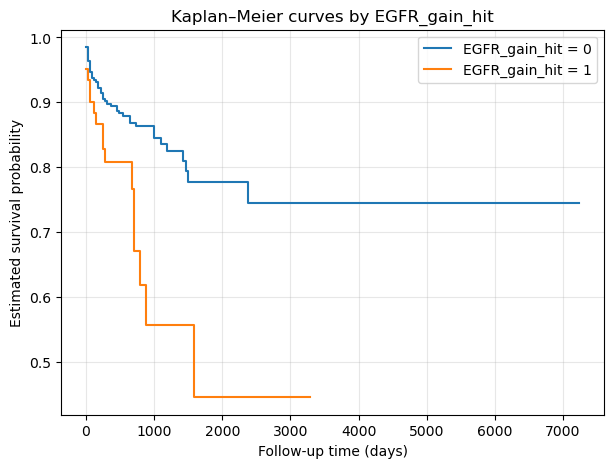

In [29]:
plt.figure(figsize=(7, 5))

for group_df, label in [
    (group_0, f"{KM_FEATURE} = 0"),
    (group_1, f"{KM_FEATURE} = 1"),
]:
    if len(group_df) == 0:
        continue

    time, survival_prob = kaplan_meier_estimator(
        event=group_df["event"].astype(bool),
        time_exit=group_df["time"].astype(float),
    )

    plt.step(time, survival_prob, where="post", label=label)

plt.xlabel("Follow-up time (days)")
plt.ylabel("Estimated survival probability")
plt.title(f"Kaplan–Meier curves by {KM_FEATURE}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Plot KM for any feature

In [30]:
def plot_km_for_feature(df, feature_col, title=None):
    # Plot Kaplan–Meier curves for a binary feature column.
    
    plt.figure(figsize=(7, 5))

    for value in [0, 1]:
        group_df = df[df[feature_col] == value].copy()
        if len(group_df) == 0:
            continue

        time, survival_prob = kaplan_meier_estimator(
            event=group_df["event"].astype(bool),
            time_exit=group_df["time"].astype(float),
        )

        plt.step(time, survival_prob, where="post", label=f"{feature_col} = {value}")

    plt.xlabel("Follow-up time (days)")
    plt.ylabel("Estimated survival probability")
    plt.title(title if title is not None else f"Kaplan–Meier curves by {feature_col}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

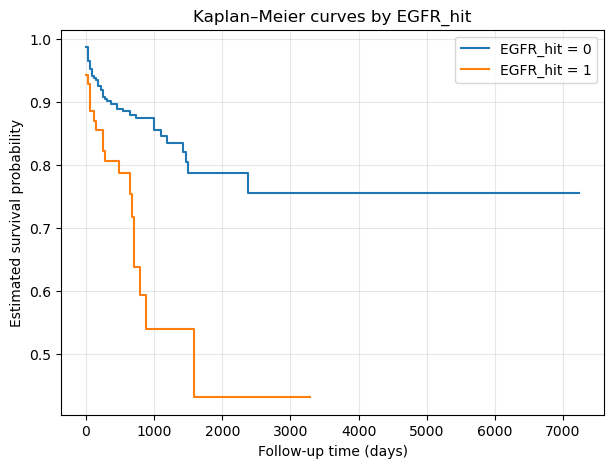

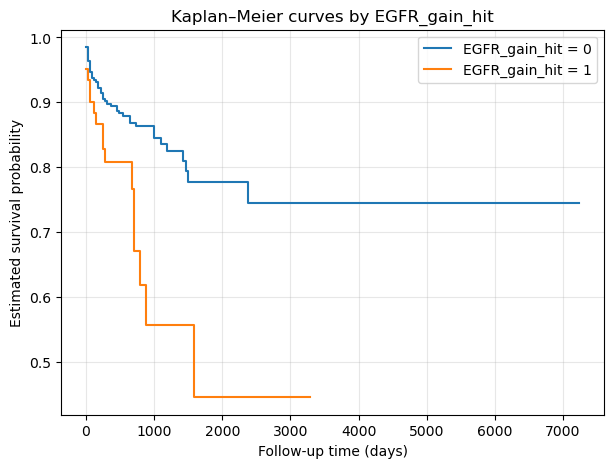

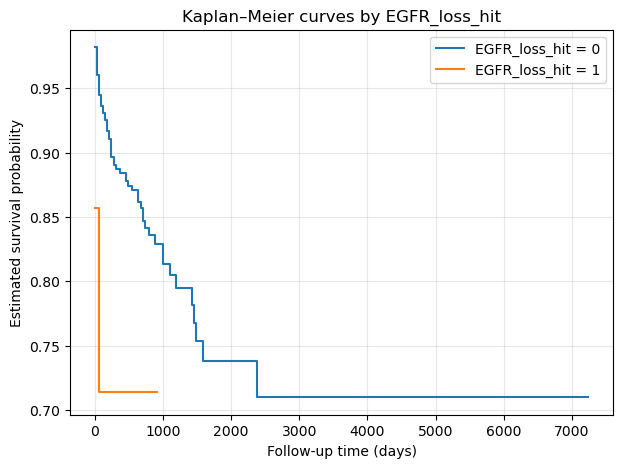

In [31]:
for feature_col in [
    f"{TARGET_GENE}_hit",
    f"{TARGET_GENE}_gain_hit",
    f"{TARGET_GENE}_loss_hit",
]:
    plot_km_for_feature(analysis_df, feature_col)

## Cox proportional hazards model

Kaplan–Meier curves are useful for visual comparison, but they do not provide a regression-based estimate of effect size.

We therefore also fit a Cox proportional hazards model.

The Cox model estimates how each feature is associated with hazard over time.  
The fitted coefficient can be interpreted as follows:

- positive coefficient → higher hazard
- negative coefficient → lower hazard

If we exponentiate the coefficient, we obtain a **hazard ratio**.

## Choose Cox model covariates

We begin with:

- one Boolean CNV feature for the target gene,
- and optionally one covariate such as sex.


In [32]:
cox_df = analysis_df.copy()

# Encode sex as a simple binary covariate if available
# Here we encode:
# female -> 0
# male   -> 1
# all other / missing -> NaN, then drop or impute
if "sex_label_individual" in cox_df.columns:
    sex_map = {
        "female": 0,
        "male": 1,
    }
    cox_df["sex_binary"] = (
        cox_df["sex_label_individual"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(sex_map)
    )
else:
    cox_df["sex_binary"] = np.nan

In [33]:
COX_FEATURES = [
    f"{TARGET_GENE}_gain_hit",
    f"{TARGET_GENE}_loss_hit",
    "sex_binary",
]

cox_model_df = cox_df.dropna(subset=["time", "event"] + COX_FEATURES).copy()

X = cox_model_df[COX_FEATURES].astype(float).copy()

y = Surv.from_arrays(
    event=cox_model_df["event"].astype(bool),
    time=cox_model_df["time"].astype(float),
)

cox_model = CoxPHSurvivalAnalysis()
cox_model.fit(X, y)

coef_df = pd.DataFrame({
    "feature": COX_FEATURES,
    "coefficient": cox_model.coef_,
    "hazard_ratio": np.exp(cox_model.coef_),
})

coef_df

,feature,coefficient,hazard_ratio
0,EGFR_gain_hit,0.882801,2.417662
1,EGFR_loss_hit,0.985796,2.679946
2,sex_binary,0.339265,1.403915


## Visualize Cox model results

The Cox model coefficients can be transformed into hazard ratios by exponentiation.

In the plot below:

- a hazard ratio of **1** indicates no association,
- values **greater than 1** indicate higher hazard,
- values **less than 1** indicate lower hazard.


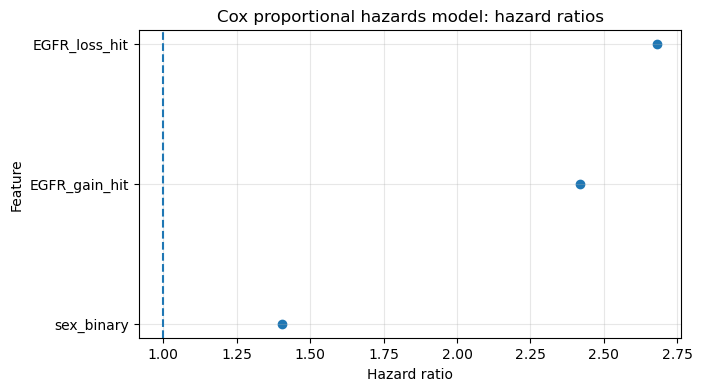

In [34]:
plt.figure(figsize=(7, 4))

plot_df = coef_df.sort_values("hazard_ratio").reset_index(drop=True)
y_pos = np.arange(len(plot_df))

plt.scatter(plot_df["hazard_ratio"], y_pos)
plt.axvline(1.0, linestyle="--")

plt.yticks(y_pos, plot_df["feature"])
plt.xlabel("Hazard ratio")
plt.ylabel("Feature")
plt.title("Cox proportional hazards model: hazard ratios")
plt.grid(alpha=0.3)
plt.show()

## Concordance index

The concordance index (C-index) measures how well the Cox model ranks samples by risk.

It can be interpreted as a survival-specific ranking metric:

- **0.5** means the model performs no better than random ranking,
- values **closer to 1** indicate better discrimination,
- and values **below 0.5** suggest that the model ranks risk poorly.

Importantly, the C-index is not the same as classification accuracy.  
It evaluates whether samples predicted to be at higher risk tend to experience the event earlier.

In [35]:
# calculate concordance index

risk_scores = cox_model.predict(X)

cindex = concordance_index_censored(
    event_indicator=cox_model_df["event"].astype(bool),
    event_time=cox_model_df["time"].astype(float),
    estimate=risk_scores,
)

print("Concordance index:", cindex[0])

Concordance index: 0.613093611672769


The concordance index is approximately **0.60**.

This suggests that the Cox model has **modest discriminatory ability**:
it performs better than random ranking, but the predictive signal is still limited.

This is not surprising in the current notebook, because the model is intentionally simple and uses only a small number of interpretable features.  

## Summary


This survival analysis notebook shows how to move from:

1. biosample-level metadata,
2. to individual-level follow-up information,
3. to biosample-level CNV records,
4. to gene-level Boolean features,
5. and finally to survival analysis.